# Notebook: 01 Starter Sample
# Purpose: load data, inspect shapes, verify dataset logic, preview masks, confirm training setup.

In [1]:
from src.utils.config import Config
from src.utils.helpers import init_notebook


config = Config.load()

init_notebook(config.train.seed)


None: None
=== init_notebook ===
Done


In [2]:
import random
import torch
import numpy as np
from src.data.annotations import load_json_annotations
from src.data.augmentations import get_val_augmentations
from src.data.loaders import ImageMaskDataset
from src.exploration.visualize import show_side_by_side, show_image, show_mask, show_overlay
from src.utils.helpers import p, t
import cv2


train_dir = config.paths.train_images
mask_dir = config.paths.train_masks
annotations_path = config.paths.annotations
entries = load_json_annotations(annotations_path)


In [3]:
# annotation count
p("Annotation entries", len(entries))


Annotation entries: 150


#### Build simple dataset with validation transforms


In [4]:
val_tf = get_val_augmentations(config.train.image_size)
dataset = ImageMaskDataset(entries, train_dir, transform = val_tf)
p("Dataset size", len(dataset))

Dataset size: 150


#### Sample inspection

=== Image 62 ===


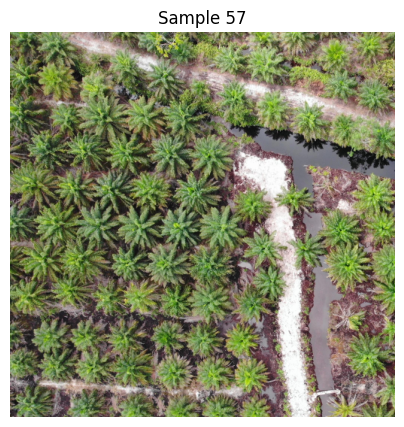

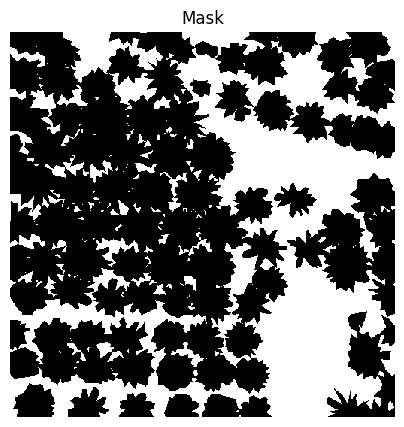

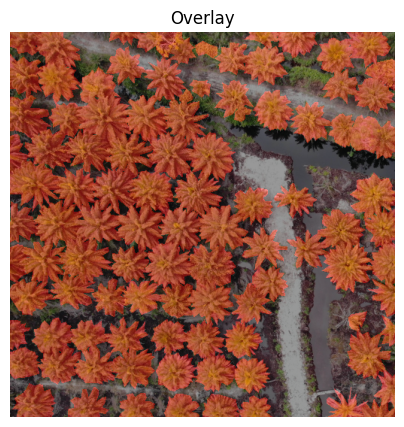

In [8]:
for _ in range(1):
    t(f"Image {idx}")
    idx = random.randint(0, len(dataset) - 1)
    img_t, mask_t = dataset[idx]

    img = img_t.permute(1, 2, 0).numpy()
    mask = mask_t.squeeze().numpy()

    titles = [f"Image {idx}", f"Mask", "Overlay"]

    show_image(img, f"Sample {idx}")
    show_mask(mask, "Mask")
    show_overlay(img, mask, 0.4, "Overlay")


=== 28 ===


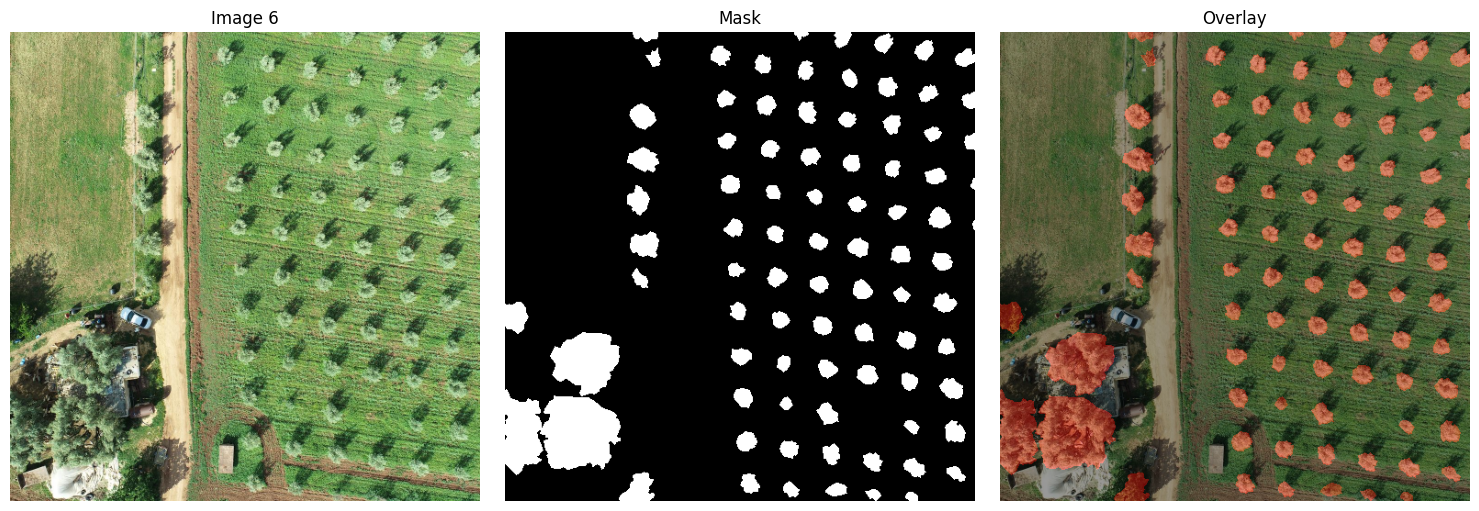

=== 6 ===


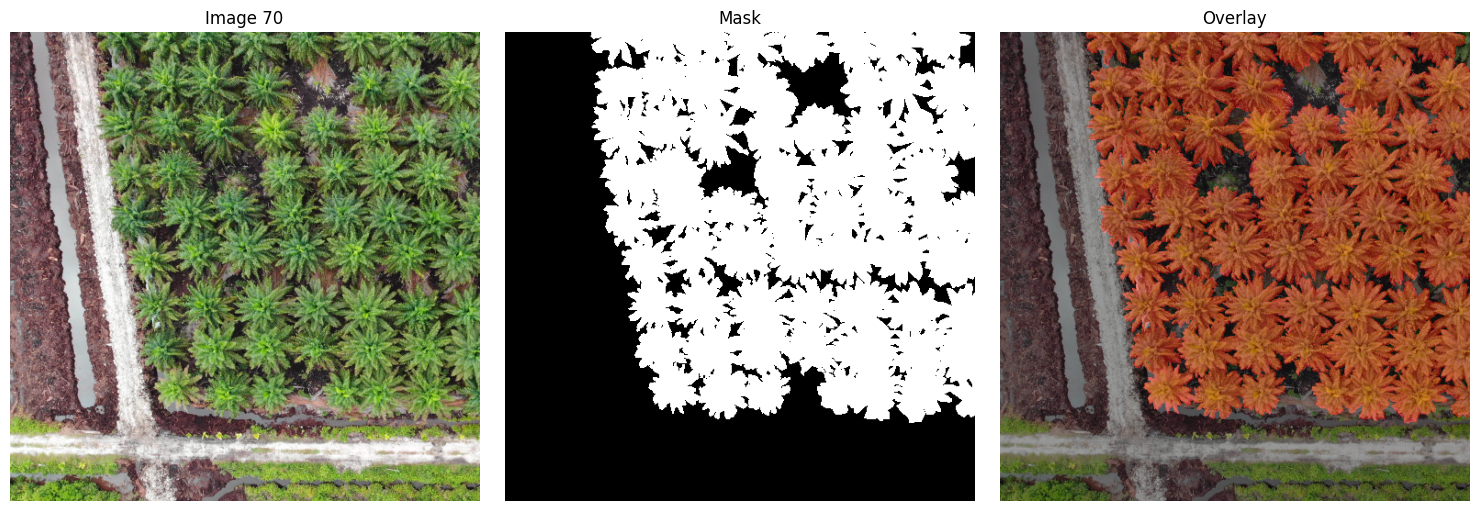

=== 70 ===


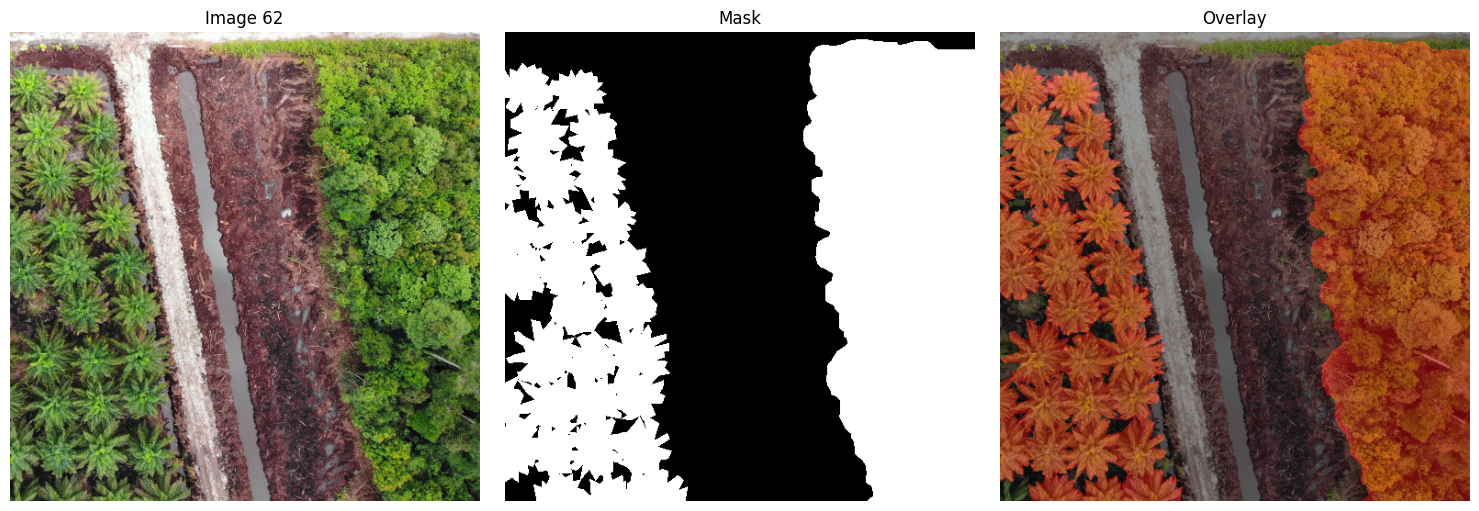

In [6]:
for _ in range(3):
    t(f"Image {idx}")
    idx = random.randint(0, len(dataset) - 1)
    img_t, mask_t = dataset[idx]

    img = img_t.permute(1, 2, 0).numpy()
    mask = mask_t.squeeze().numpy()

    titles = [f"Image {idx}", f"Mask", "Overlay"]

    if img.max() <= 1.0:
        base = (img * 255).astype(np.uint8)
    else:
        base = img.astype(np.uint8)

    mask_u8 = (mask * 255).astype(np.uint8)
    mask_rgb = np.zeros_like(base)
    mask_rgb[:, :, 0] = mask_u8
    overlay = cv2.addWeighted(base, 0.6, mask_rgb, 0.4, 0)

    show_side_by_side(img, mask, overlay, titles = titles)




#### Testing forward pass with a small model

In [9]:
from src.models.simple_cnn import SimpleCNN


model = SimpleCNN(in_channels = 3, out_channels = 1)
model.eval()

sample_img, sample_mask = dataset[0]
sample_img = sample_img.unsqueeze(0)

with torch.no_grad():
    out = model(sample_img)

p("Forward pass result shape", out.shape)


Forward pass result shape: 4 items
  0: 1
  1: 1
  2: 512
  3: 512
